<a href="https://colab.research.google.com/github/RRADJon/TEMPO/blob/main/Working/AOP_Dataset_Merging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Load datasets
!pip install -q rdkit

import pandas as pd
import requests
import gzip
import io
from rdkit import Chem

PCBA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/pcba.csv.gz"

print("Downloading PCBA dataset...")
response = requests.get(PCBA_URL)

print("Reading dataset...")
df_pcba = pd.read_csv(gzip.open(io.BytesIO(response.content), "rt"), low_memory=False)
print("Original PCBA size:", df_pcba.shape)

# Identify assay columns
pcba_tasks = [c for c in df_pcba.columns if c.startswith("PCBA-")]
print("Assays detected:", len(pcba_tasks))
print("Compounds:", len(df_pcba))

# Filter invalid SMILES
def valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

print("Filtering invalid molecules...")
df_pcba = df_pcba[df_pcba["smiles"].apply(valid_smiles)]
print("Clean PCBA size:", df_pcba.shape)

# Convert activity to binary
df_pcba[pcba_tasks] = df_pcba[pcba_tasks].fillna(0)
df_pcba[pcba_tasks] = (df_pcba[pcba_tasks] > 0).astype(int)
df_pcba.head()

# Load SIDER dataset
SIDER_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/sider.csv.gz"
print("Downloading SIDER dataset...")
response = requests.get(SIDER_URL)
df_sider = pd.read_csv(gzip.open(io.BytesIO(response.content), "rt"))
print("SIDER loaded:", df_sider.shape)

# Side effect columns
sider_tasks = [c for c in df_sider.columns if c != "smiles"]
print("Side effect categories:", len(sider_tasks))

df_sider.head()

# Load ClinTox dataset
CLINTOX_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
print("Downloading ClinTox dataset...")
response = requests.get(CLINTOX_URL)

df_clintox = pd.read_csv(gzip.open(io.BytesIO(response.content), "rt"))

print("ClinTox loaded:", df_clintox.shape)

df_clintox.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 23.3 MB/s eta 0:00:00
Reading dataset...
Original PCBA size: (437929, 130)
Assays detected: 128
Compounds: 437929
Filtering invalid molecules...


[16:31:31] Explicit valence for atom # 4 Al, 5, is greater than permitted
[16:31:50] WARNING: not removing hydrogen atom without neighbors
[16:32:01] WARNING: not removing hydrogen atom without neighbors
[16:32:45] WARNING: not removing hydrogen atom without neighbors
[16:32:52] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:32:56] WARNING: not removing hydrogen atom without neighbors


Clean PCBA size: (437927, 130)
SIDER loaded: (1427, 28)
Side effect categories: 27
ClinTox loaded: (1484, 3)


,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0
3,[H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...,1,0
4,[H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...,1,0


In [ ]:
#@title Canonicalize SMILES

from rdkit import Chem

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol)
        return None
    except:
        return None

print("Canonicalizing SMILES...")

df_pcba["smiles"] = df_pcba["smiles"].apply(canonicalize)
df_sider["smiles"] = df_sider["smiles"].apply(canonicalize)
df_clintox["smiles"] = df_clintox["smiles"].apply(canonicalize)

df_pcba = df_pcba.dropna(subset=["smiles"])
df_sider = df_sider.dropna(subset=["smiles"])
df_clintox = df_clintox.dropna(subset=["smiles"])

print("Canonicalization complete")

Canonicalizing SMILES...


[16:34:26] WARNING: not removing hydrogen atom without neighbors
[16:34:43] WARNING: not removing hydrogen atom without neighbors
[16:35:53] WARNING: not removing hydrogen atom without neighbors
[16:36:07] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:58] WARNING: not removing hydrogen atom without neighbors
[16:36:59] WARNING: not r

Canonicalization complete


In [ ]:
#@title Merge toxicity labels

tox_df = pd.merge(
    df_sider[["smiles"] + sider_tasks],
    df_clintox[["smiles", "CT_TOX"]],
    on="smiles",
    how="inner"
)

print("Merged toxicity dataset:", tox_df.shape)

tox_df.head()

Merged toxicity dataset: (273, 29)


,smiles,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,...,Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications",CT_TOX
0,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,1,1,0,1,1,1,1,0,1,...,1,1,1,1,0,1,1,1,1,0
1,CCCSc1nc(N[C@@H]2C[C@H]2c2ccc(F)c(F)c2)c2nnn([...,0,1,0,1,1,1,1,0,1,...,0,1,1,1,0,1,1,1,1,0
2,CC(C)Cn1cnc2c(N)nc3ccccc3c21,1,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,CCCCC(=O)O[C@]1(C(=O)CO)[C@@H](C)C[C@H]2[C@@H]...,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
4,CC(=O)[O-],0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
#@title Data Check
print("Dataset sizes:")
df_hpa = pd.read_csv("normal_ihc_data.tsv", sep="\t")
print("PCBA:", df_pcba.shape)
print("SIDER:", df_sider.shape)
print("ClinTox:", df_clintox.shape)
print("Merged toxicity:", tox_df.shape)
print("HPA data:", df_hpa.shape)

df_hpa.head()

Dataset sizes:
PCBA: (437927, 130)
SIDER: (1427, 28)
ClinTox: (1480, 3)
Merged toxicity: (273, 29)
HPA data: (1199675, 7)


,Gene,Gene name,Tissue,IHC tissue name,Cell type,Level,Reliability
0,ENSG00000000003,TSPAN6,Adipose tissue,Adipose tissue,adipocytes,Not detected,Approved
1,ENSG00000000003,TSPAN6,Adrenal gland,Adrenal gland,glandular cells,Not detected,Approved
2,ENSG00000000003,TSPAN6,Appendix,Appendix,glandular cells,Medium,Approved
3,ENSG00000000003,TSPAN6,Appendix,Appendix,lymphoid tissue,Not detected,Approved
4,ENSG00000000003,TSPAN6,Bone marrow,Bone marrow,hematopoietic cells,Not detected,Approved


In [ ]:
#@title Build compound-target activity matrix

activity_df = df_pcba[["smiles"] + pcba_tasks]

# convert actives to binary
activity_df[pcba_tasks] = activity_df[pcba_tasks].applymap(
    lambda x: 1 if x > 0 else 0
)

print(activity_df.head())

/tmp/ipykernel_420/1495334867.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  activity_df[pcba_tasks] = activity_df[pcba_tasks].applymap(
/tmp/ipykernel_420/1495334867.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activity_df[pcba_tasks] = activity_df[pcba_tasks].applymap(


                                              smiles  PCBA-1030  PCBA-1379  \
0               CC(=O)N1CCC2(CC1)NC(=O)N(c1ccccc1)N2          0          0   
1                         N#Cc1nnn(-c2ccc(Cl)cc2)c1N          0          0   
2      COC(=O)c1ccc(NC(=O)c2ccccc2CC[N+](=O)[O-])cc1          0          0   
3            CCC1NC(=O)c2cccnc2-n2c1nc1ccc(F)cc1c2=O          0          0   
4  CC1=CC(=O)/C(=C2/C=C(C(=O)Nc3ccc(S(=O)(=O)Nc4o...          0          0   

   PCBA-1452  PCBA-1454  PCBA-1457  PCBA-1458  PCBA-1460  PCBA-1461  \
0          0          0          0          0          0          0   
1          0          0          0          0          0          0   
2          0          0          0          0          0          0   
3          0          0          0          0          0          0   
4          0          0          0          0          0          0   

   PCBA-1468  ...  PCBA-904  PCBA-912  PCBA-914  PCBA-915  PCBA-924  PCBA-925  \
0          0  ...      

In [ ]:
#@title Fetch Scientific Names for all PCBA Assays
import requests
import time

print(f"Fetching titles for {len(pcba_tasks)} assays. This will take about 1-2 minutes...")
print("-" * 50)

# Dictionary to store the results
assay_titles = {}

for i, assay_label in enumerate(pcba_tasks):
    # Extract the numerical AID (e.g., '1454' from 'PCBA-1454')
    aid = assay_label.replace("PCBA-", "")

    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/{aid}/summary/JSON"

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            # Navigate the JSON structure to get the Name
            name = data['AssaySummaries']['AssaySummary'][0]['Name']
            assay_titles[assay_label] = name
            print(f"[{i+1}/{len(pcba_tasks)}] {assay_label}: {name}")
        else:
            print(f"[{i+1}/{len(pcba_tasks)}] {assay_label}: Error (Status {response.status_code})")

    except Exception as e:
        print(f"[{i+1}/{len(pcba_tasks)}] {assay_label}: Failed to fetch data.")

    # Respectful pause for the PubChem API
    time.sleep(0.2)

print("-" * 50)
print(f"Done! Successfully retrieved {len(assay_titles)} titles.")

Fetching titles for 128 assays. This will take about 1-2 minutes...
--------------------------------------------------
[1/128] PCBA-1030: qHTS Assay for Inhibitors of Aldehyde Dehydrogenase 1 (ALDH1A1)
[2/128] PCBA-1379: Counterscreen for Luciferase (Kinase-Glo TM) Inhibition
[3/128] PCBA-1452: qHTS Assay for Inhibitors of 12-hLO (12-human lipoxygenase)
[4/128] PCBA-1454: qHTS Assay for Inhibitors of the ERK Signaling Pathway using a Homogeneous Screening Assay; Stimulation with EGF
[5/128] PCBA-1457: qHTS Assay for Identifying the Cell-Membrane Permeable IMPase Inhibitors: Potentiation with Lithium
[6/128] PCBA-1458: qHTS Assay for Enhancers of SMN2 Splice Variant Expression
[7/128] PCBA-1460: qHTS for Inhibitors of Tau Fibril Formation, Thioflavin T Binding
[8/128] PCBA-1461: qHTS Assay for Antagonists of the Neuropeptide S Receptor: cAMP Signal Transduction
[9/128] PCBA-1468: qHTS for Inhibitors of Tau Fibril Formation, Fluorescence Polarization
[10/128] PCBA-1469: qHTS for Inhibito

In [ ]:
#@title Final Parsed PCBA-to-Protein Mapping

pcba_protein_map = {
    # Metabolic & Enzymes
    "PCBA-1030": "ALDH1A1", "PCBA-1452": "ALOX12", "PCBA-1631": "PKM2",
    "PCBA-1634": "PKM2", "PCBA-1721": "PKM", "PCBA-2100": "GAA",
    "PCBA-2101": "GBA", "PCBA-2242": "GAA", "PCBA-2451": "ALDOA",
    "PCBA-602233": "PGK1", "PCBA-624170": "GLS", "PCBA-651965": "CLPP",

    # Signaling & Kinases
    "PCBA-1454": "ERK", "PCBA-1460": "MAPT", "PCBA-1461": "NPSR1",
    "PCBA-1468": "MAPT", "PCBA-1469": "THRB", "PCBA-493208": "MTOR",
    "PCBA-2662": "MLL", "PCBA-2676": "RXFP1", "PCBA-995": "ERK",
    "PCBA-720707": "EPAC1", "PCBA-720708": "EPAC2", "PCBA-720709": "EPAC1",
    "PCBA-720711": "EPAC2",

    # DNA Repair & Helicases
    "PCBA-2147": "KDM4E", "PCBA-2326": "NS1", "PCBA-2517": "APEX1",
    "PCBA-2528": "BLM", "PCBA-2549": "RECQ1", "PCBA-485290": "TDP1",
    "PCBA-485314": "POLB", "PCBA-588579": "POLK", "PCBA-588590": "POLI",
    "PCBA-588591": "POLH", "PCBA-588795": "FEN1", "PCBA-651768": "WRN",
    "PCBA-686978": "TDP1", "PCBA-686979": "TDP1",

    # Transcription & Receptors
    "PCBA-2546": "RORC", "PCBA-2551": "RORC", "PCBA-504706": "TP53",
    "PCBA-504847": "VDR", "PCBA-624171": "NFE2L2", "PCBA-624202": "BRCA1",
    "PCBA-624246": "ERG", "PCBA-624417": "GLP1R", "PCBA-743266": "PTH1R",
    "PCBA-926": "TSHR", "PCBA-938": "TSHR",

    # Epigenetics & Ubiquitin
    "PCBA-485360": "L3MBTL1", "PCBA-504327": "GCN5", "PCBA-504332": "EHMT2",
    "PCBA-504333": "BAZ2B", "PCBA-504339": "KDM4A", "PCBA-463254": "USP2",
    "PCBA-743255": "USP1", "PCBA-927": "USP2",

    # Metabolism (CYP450) - Major Toxicity Targets
    "PCBA-883": "CYP2C9", "PCBA-884": "CYP3A4", "PCBA-885": "CYP3A4",
    "PCBA-891": "CYP2D6", "PCBA-899": "CYP2C19",

    # Stress & Toxicity
    "PCBA-504444": "NFE2L2", "PCBA-588453": "TXNRD1", "PCBA-588456": "TXNRD1",
    "PCBA-602332": "ERSR", "PCBA-914": "HRE", "PCBA-915": "HRE"
}

protein_list = list(set(pcba_protein_map.values()))
print(f"Mapped {len(pcba_protein_map)} assays to {len(protein_list)} biological targets.")

Mapped 69 assays to 54 biological targets.


In [ ]:
#@title Integration Pipeline: Protein Toxicity Enrichment

import numpy as np
import pandas as pd

# --- PART 1: Merge PCBA and Toxicity Data ---
# Merging on SMILES to identify molecules present in both datasets
merged = pd.merge(activity_df, tox_df, on="smiles")
print(f"Analyzing {len(merged)} molecules with both activity and toxicity data.")

# --- PART 2: Protein Toxicity Enrichment ---
protein_stats = {} # Using a dict to store [toxic_fractions, active_counts]

# Check each protein in our new mapping
for assay, protein in pcba_protein_map.items():
    if assay not in merged.columns:
        continue

    # Identify compounds active (1) in this specific assay
    active_compounds = merged[merged[assay] == 1]
    num_actives = len(active_compounds)

    if num_actives < 1:
        # print(f"Target {protein} ({assay}): No active compounds found.") # Optional debug
        continue

    # Calculate the percentage of these active compounds that are toxic (CT_TOX)
    toxic_fraction = active_compounds["CT_TOX"].mean()

    if protein not in protein_stats:
        protein_stats[protein] = {"fractions": [], "counts": []}

    protein_stats[protein]["fractions"].append(toxic_fraction)
    protein_stats[protein]["counts"].append(num_actives)

# Finalize protein scores
protein_final_scores = {}
protein_total_actives = {}

for protein, data in protein_stats.items():
    # Weighted average of toxicity fractions based on the number of actives per assay
    avg_tox = np.mean(data["fractions"])
    total_n = np.sum(data["counts"])

    protein_final_scores[protein] = avg_tox
    protein_total_actives[protein] = total_n

# --- PART 3: Expression Scoring (Handling missing df_hpa) ---
expression_scores = {}

if 'df_hpa' not in locals():
    print("\nNote: df_hpa not found. Using baseline expression (0.5) for calculations.")
    for protein in protein_final_scores:
        expression_scores[protein] = 0.5
else:
    level_map = {"High": 1.0, "Medium": 0.6, "Low": 0.3, "Not detected": 0}
    for protein in protein_final_scores:
        subset = df_hpa[df_hpa["Gene name"] == protein]
        if len(subset) == 0:
            expression_scores[protein] = 0.2 # Small baseline for unknown genes
        else:
            expr = subset["Level"].map(level_map).mean()
            expression_scores[protein] = expr

# --- PART 4: Final Ranking & Confidence Filter ---
final_output = []
MIN_ACTIVES = 1 # Increase this to 3 or 5 for more "confident" results

for protein, activity_score in protein_final_scores.items():
    count = protein_total_actives[protein]
    if count < MIN_ACTIVES:
        continue

    expr_score = expression_scores.get(protein, 0)

    # Final Formula: 70% Toxicity Enrichment | 30% Tissue Expression
    total_score = (0.7 * activity_score) + (0.3 * expr_score)
    final_output.append({
        "Protein": protein,
        "Actives": count,
        "Tox_Fraction": activity_score,
        "Final_Score": total_score
    })

# Convert to DataFrame for pretty printing and sorting
results_df = pd.DataFrame(final_output).sort_values(by="Final_Score", ascending=False)

print("\n--- Top Toxicity Proteins (Ranked by Enrichment & Expression) ---")
if results_df.empty:
    print("No proteins met the criteria.")
else:
    # Formatting for clarity
    print(results_df.to_string(index=False, formatters={
        'Tox_Fraction': '{:,.2f}'.format,
        'Final_Score': '{:,.4f}'.format
    }))

print(f"\nAnalysis complete. Found {len(results_df)} proteins with active molecules in the overlap.")

Analyzing 225 molecules with both activity and toxicity data.

--- Top Toxicity Proteins (Ranked by Enrichment & Expression) ---
Protein  Actives Tox_Fraction Final_Score
   POLI        1         1.00      0.7877
    BLM        2         0.50      0.6003
 NFE2L2        6         0.50      0.5445
   POLH        2         0.50      0.5087
   POLB        2         0.50      0.4515
  APEX1        3         0.33      0.4271
   POLK        2         0.50      0.4100
    ERK        4         0.50      0.4100
   GCN5        2         0.50      0.4100
  KDM4E        4         0.25      0.3858
   TDP1       91         0.30      0.3130
  RECQ1        3         0.33      0.2933
  EHMT2       14         0.29      0.2786
   MAPT        9         0.32      0.2562
  ALDOA        5         0.20      0.2463
  KDM4A       11         0.18      0.2311
 TXNRD1        1         0.00      0.1899
  BAZ2B        9         0.11      0.1853
  NPSR1        6         0.17      0.1767
   RORC       14         0.15  

In [ ]:
print("Overlap between PCBA and tox dataset:")

overlap = set(df_pcba["smiles"]) & set(tox_df["smiles"])

print("Shared molecules:", len(overlap))

Overlap between PCBA and tox dataset:
Shared molecules: 213


In [ ]:
#@title Tissue-Specific Toxicity Analysis
# 1. Standardize HPA data
# Ensure Gene names are uppercase and Tissues are lowercase for easy matching
df_hpa['Gene name'] = df_hpa['Gene name'].str.upper().str.strip()
df_hpa['Tissue'] = df_hpa['Tissue'].str.lower().str.strip()

# 2. Map the 'Level' strings to numerical values
level_map = {"High": 1.0, "Medium": 0.6, "Low": 0.3, "Not detected": 0.0}
df_hpa['Score'] = df_hpa['Level'].map(level_map)

# 3. Define target tissues (Must be lowercase to match our standardized df_hpa)
target_tissues = ['liver', 'heart muscle', 'kidney', 'brain', 'lung']

# 4. Create Pivot Table
tissue_pivot = df_hpa[df_hpa['Tissue'].isin(target_tissues)].pivot_table(
    index='Gene name',
    columns='Tissue',
    values='Score',
    aggfunc='max'
).reset_index()

# 5. Standardize your results_df
results_df['Protein'] = results_df['Protein'].str.upper().str.strip()

# 6. Merge
final_integration = pd.merge(
    results_df,
    tissue_pivot,
    left_on='Protein',
    right_on='Gene name',
    how='inner'
)

# 7. Calculate Liver Risk (safely handling if 'liver' column exists)
if 'liver' in final_integration.columns:
    final_integration['Liver_Risk'] = final_integration['Tox_Fraction'] * final_integration['liver']
else:
    final_integration['Liver_Risk'] = 0
    print("Warning: 'liver' tissue not found in HPA subset.")

# 8. Output results
print(f"Successfully matched {len(final_integration)} proteins to HPA tissue data.")

if not final_integration.empty:
    cols_to_show = ['Protein', 'Actives', 'Tox_Fraction', 'liver', 'heart muscle', 'Liver_Risk']
    # Filter columns to only those that exist (in case a tissue was missing)
    existing_cols = [c for c in cols_to_show if c in final_integration.columns]
    print("\n--- Integrated Protein-Tissue Risk Table ---")
    print(final_integration[existing_cols].sort_values(by='Liver_Risk', ascending=False).head(15).to_string(index=False))
else:
    print("Merge still resulted in an empty set. Checking Gene name examples:")
    print("Results Gene Sample:", results_df['Protein'].head(3).tolist())
    print("HPA Gene Sample:", df_hpa['Gene name'].head(3).tolist())

Successfully matched 24 proteins to HPA tissue data.

--- Integrated Protein-Tissue Risk Table ---
Protein  Actives  Tox_Fraction  liver  heart muscle  Liver_Risk
   POLH        2      0.500000    0.6           0.6    0.300000
 NFE2L2        6      0.500000    0.6           0.6    0.300000
   POLB        2      0.500000    0.6           0.0    0.300000
  APEX1        3      0.333333    0.6           0.3    0.200000
   TDP1       91      0.297619    0.6           0.6    0.178571
    BLM        2      0.500000    0.3           1.0    0.150000
  KDM4E        4      0.250000    0.6           0.6    0.150000
 CYP2D6        8      0.125000    1.0           0.0    0.125000
 CYP3A4       24      0.068182    1.0           0.0    0.068182
  ALDOA        5      0.200000    0.3           0.0    0.060000
  KDM4A       11      0.181818    0.3           0.3    0.054545
  BAZ2B        9      0.111111    0.3           0.6    0.033333
   POLI        1      1.000000    0.0           0.3    0.000000
 TXNR

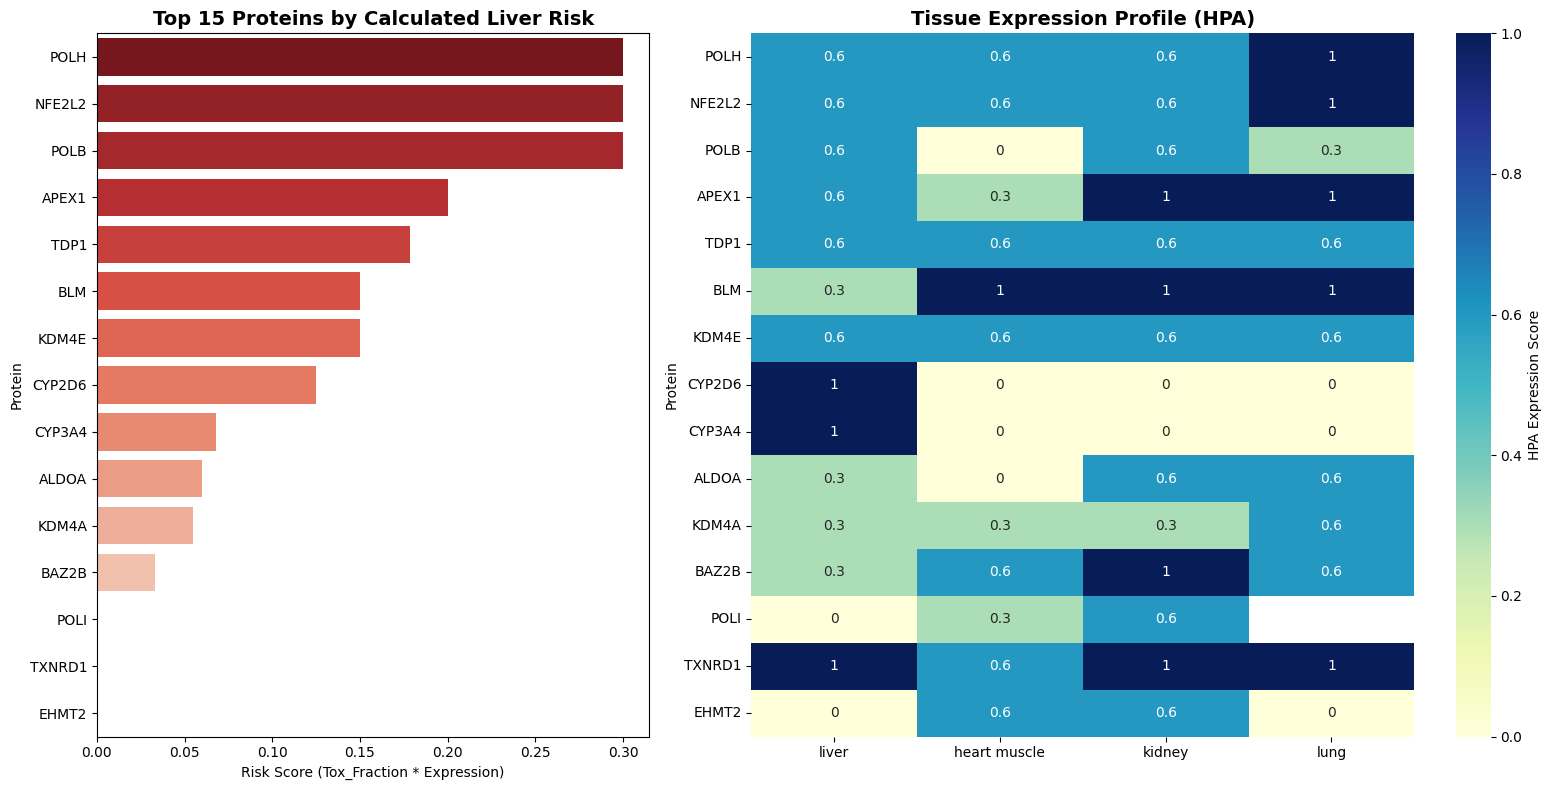

In [ ]:
#@title Figure
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
# We'll take the top 15 proteins by Liver_Risk to keep the chart readable
plot_df = final_integration.sort_values(by='Liver_Risk', ascending=False).head(15)

if not plot_df.empty:
    # Create a figure with two subplots: a Bar Chart and a Heatmap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.5]})

    # --- Plot 1: Bar Chart ---
    sns.barplot(
        data=plot_df,
        x='Liver_Risk',
        y='Protein',
        hue='Protein',
        palette='Reds_r',
        legend=False,
        ax=ax1
    )

    ax1.set_title('Top 15 Proteins by Calculated Liver Risk', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Risk Score (Tox_Fraction * Expression)')

    # --- Plot 2: Heatmap ---
    available_tissues = [t for t in target_tissues if t in plot_df.columns]

    if len(available_tissues) == 0:
        print("No matching tissue columns found for heatmap.")
    else:
        heatmap_data = plot_df.set_index('Protein')[available_tissues]

        sns.heatmap(
            heatmap_data,
            annot=True,
            cmap='YlGnBu',
            cbar_kws={'label': 'HPA Expression Score'},
            ax=ax2
        )

        ax2.set_title('Tissue Expression Profile (HPA)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot. Please check your merge results.")

In [ ]:
#@title Prepare SIDER labels
# We look for molecules that have 'Hepatobiliary disorders' (liver side effects)
liver_col = 'Hepatobiliary disorders'
if liver_col in df_sider.columns:
    # Get a list of "toxic" molecules according to SIDER
    sider_liver_smiles = df_sider[df_sider[liver_col] == 1]['smiles'].unique()

    # 2. Check compounds active for our top proteins
    print(f"{'Protein':<12} | {'SIDER Liver Match %':<20} | {'Status'}")
    print("-" * 50)

    for protein in final_integration['Protein'].unique():
        # Find which assays map to this protein
        assays = [a for a, p in pcba_protein_map.items() if p == protein]

        # Get molecules active in these assays within our merged set
        active_smiles = merged[merged[assays].sum(axis=1) > 0]['smiles'].unique()

        if len(active_smiles) > 0:
            # Calculate how many of these compounds actually cause liver issues in SIDER
            match_count = len(set(active_smiles) & set(sider_liver_smiles))
            match_pct = (match_count / len(active_smiles)) * 100

            status = "High" if match_pct > 50 else "Moderate"
            print(f"{protein:<12} | {match_pct:>18.1f}% | {status}")
else:
    print("SIDER liver column not found. Check df_sider.columns for exact name.")

Protein      | SIDER Liver Match %  | Status
--------------------------------------------------
POLI         |              100.0% | High
BLM          |               50.0% | Moderate
NFE2L2       |               50.0% | Moderate
POLH         |               50.0% | Moderate
POLB         |               50.0% | Moderate
APEX1        |               66.7% | High
KDM4E        |              100.0% | High
TDP1         |               68.1% | High
EHMT2        |               69.2% | High
MAPT         |               75.0% | High
ALDOA        |              100.0% | High
KDM4A        |               66.7% | High
TXNRD1       |              100.0% | High
BAZ2B        |               50.0% | Moderate
PKM          |                0.0% | Moderate
CLPP         |              100.0% | High
CYP2D6       |               62.5% | High
USP1         |              100.0% | High
CYP3A4       |               62.5% | High
GAA          |               66.7% | High
ALDH1A1      |               75.0% | Hig

['Hepatobiliary disorders', 'Metabolism and nutrition disorders', 'Product issues', 'Eye disorders', 'Investigations', 'Musculoskeletal and connective tissue disorders', 'Gastrointestinal disorders', 'Social circumstances', 'Immune system disorders', 'Reproductive system and breast disorders', 'Neoplasms benign, malignant and unspecified (incl cysts and polyps)', 'General disorders and administration site conditions', 'Endocrine disorders', 'Surgical and medical procedures', 'Vascular disorders', 'Blood and lymphatic system disorders', 'Skin and subcutaneous tissue disorders', 'Congenital, familial and genetic disorders', 'Infections and infestations', 'Respiratory, thoracic and mediastinal disorders', 'Psychiatric disorders', 'Renal and urinary disorders', 'Pregnancy, puerperium and perinatal conditions', 'Ear and labyrinth disorders', 'Cardiac disorders', 'Nervous system disorders', 'Injury, poisoning and procedural complications']


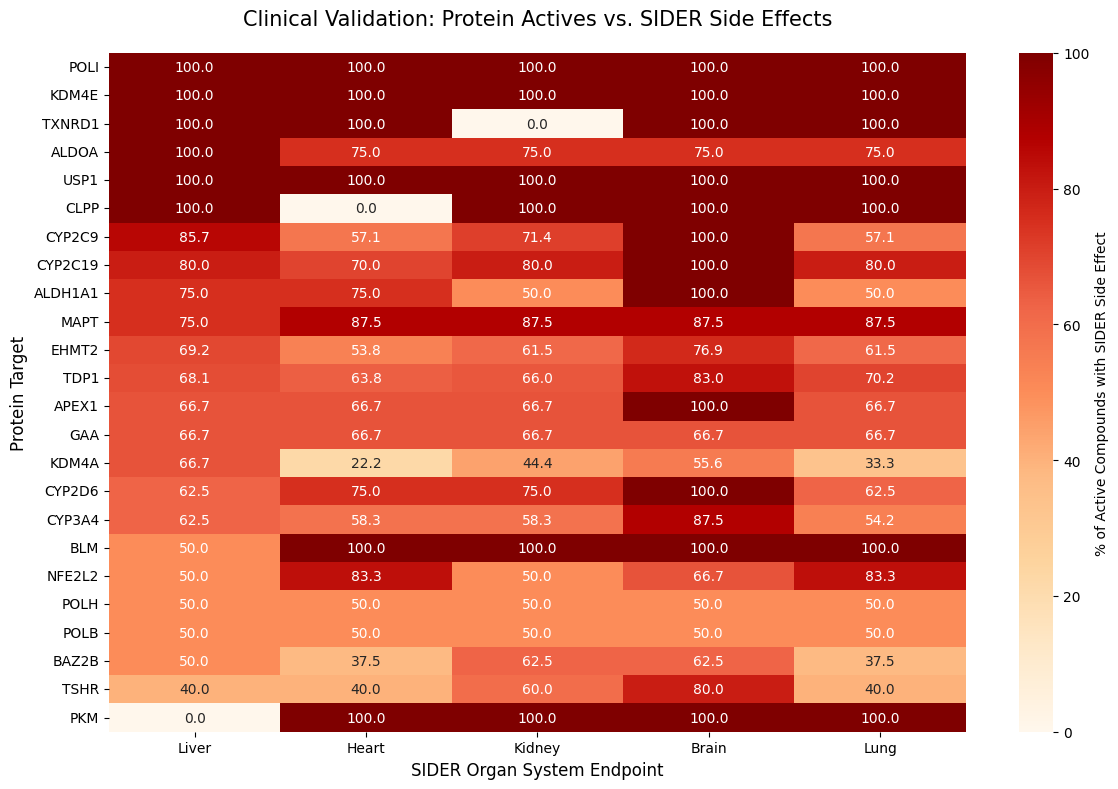

In [ ]:
#@title Additional SIDER labels

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sider_tasks = [c for c in df_sider.columns if c != "smiles"]
print(sider_tasks)

# 1. Define the SIDER endpoints to analyze
# These should match column names in your df_sider
endpoint_map = {
    'Hepatobiliary disorders': 'Liver',
    'Cardiac disorders': 'Heart',
    'Renal and urinary disorders': 'Kidney',
    'Nervous system disorders': 'Brain',
    'Respiratory, thoracic and mediastinal disorders': 'Lung'
}

# Ensure endpoints exist in df_sider
available_endpoints = [e for e in endpoint_map.keys() if e in df_sider.columns]
results_list = []

# 2. Iterate through proteins and calculate match % for each endpoint
for protein in final_integration['Protein'].unique():
    # Find assays for this protein
    assays = [a for a, p in pcba_protein_map.items() if p == protein]

    # Get active molecules for these assays
    # (Assuming 'merged' df contains assay columns and 'smiles')
    active_smiles = merged[merged[assays].sum(axis=1) > 0]['smiles'].unique()

    if len(active_smiles) > 0:
        protein_results = {'Protein': protein}

        for col in available_endpoints:
            # SIDER molecules for this specific disorder
            sider_smiles = df_sider[df_sider[col] == 1]['smiles'].unique()

            # Calculate overlap %
            match_count = len(set(active_smiles) & set(sider_smiles))
            match_pct = (match_count / len(active_smiles)) * 100

            # Store with the display name
            protein_results[endpoint_map[col]] = match_pct

        results_list.append(protein_results)

# 3. Create a DataFrame for plotting
validation_df = pd.DataFrame(results_list).set_index('Protein')

# 4. Generate the Visualization
if not validation_df.empty:
    plt.figure(figsize=(12, 8))

    # Sort by Liver match % by default to maintain consistency with previous analysis
    if 'Liver' in validation_df.columns:
        validation_df = validation_df.sort_values(by='Liver', ascending=False)

    sns.heatmap(
        validation_df,
        annot=True,
        fmt=".1f",
        cmap="OrRd",
        cbar_kws={'label': '% of Active Compounds with SIDER Side Effect'}
    )

    plt.title('Clinical Validation: Protein Actives vs. SIDER Side Effects', fontsize=15, pad=20)
    plt.xlabel('SIDER Organ System Endpoint', fontsize=12)
    plt.ylabel('Protein Target', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No matching data found to plot. Ensure 'merged' and 'df_sider' share SMILES.")

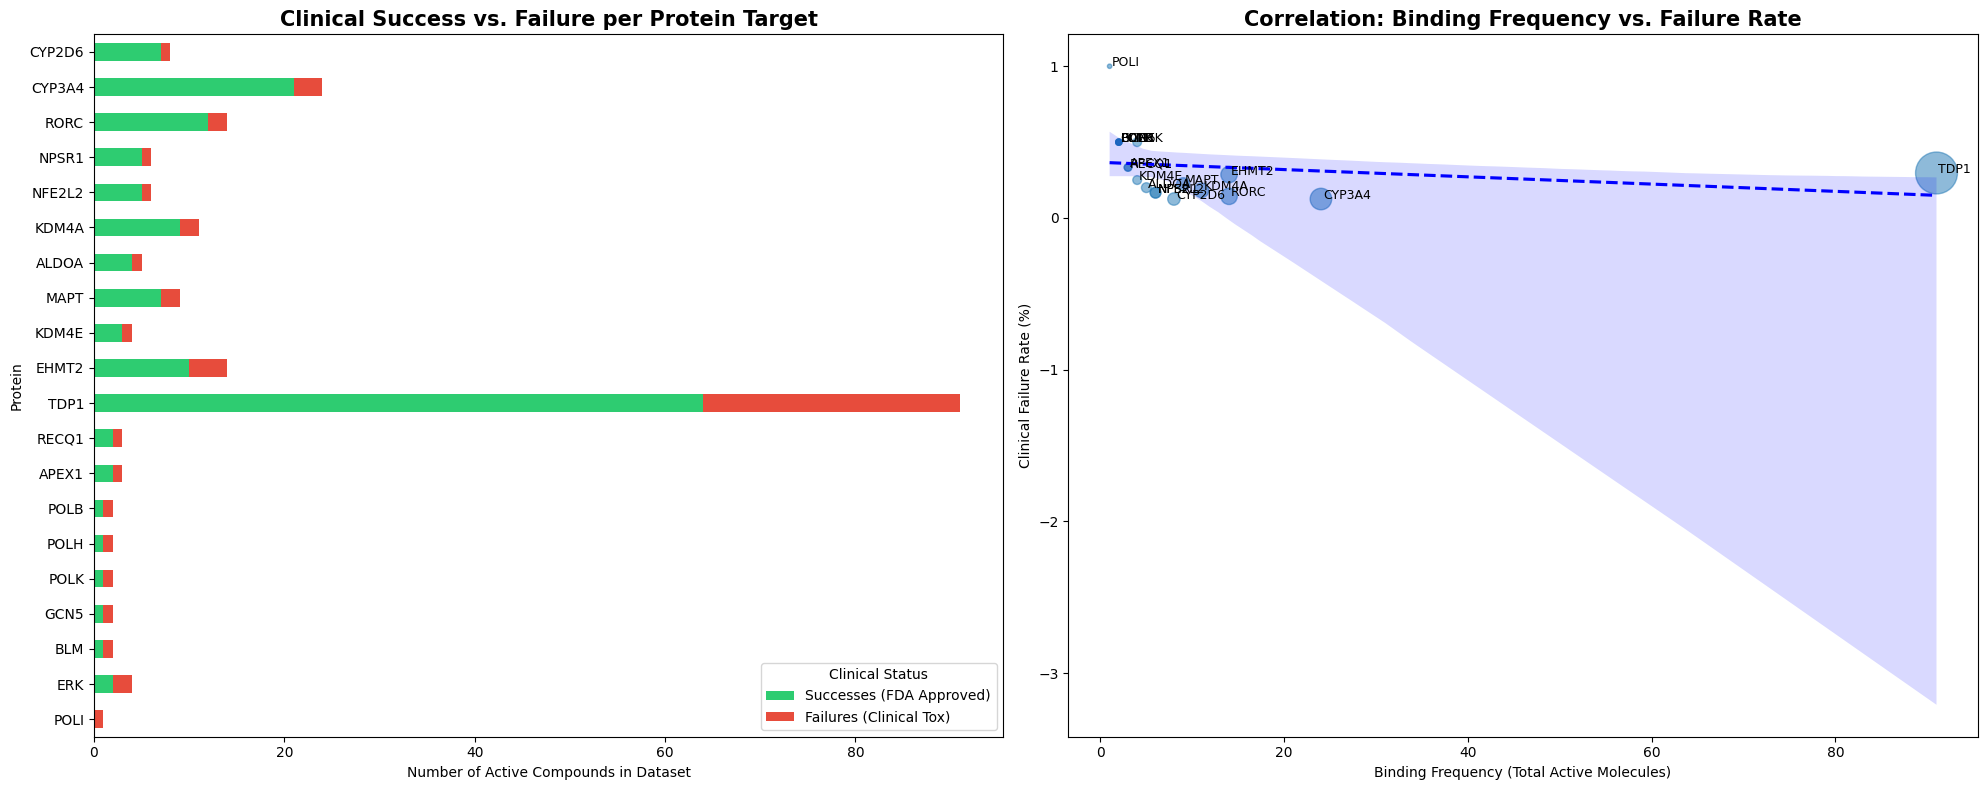

In [ ]:
#@title outputFigures
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Success vs. Failure counts for each protein
clinical_data = []

for assay, protein in pcba_protein_map.items():
    if assay not in merged.columns:
        continue

    # Filter molecules active for this protein
    actives = merged[merged[assay] == 1]

    if len(actives) > 0:
        # 0 = FDA Approved (Success), 1 = Clinical Failure (Tox)
        failures = actives['CT_TOX'].sum()
        successes = len(actives) - failures
        failure_rate = failures / len(actives)

        clinical_data.append({
            'Protein': protein,
            'Successes (FDA Approved)': successes,
            'Failures (Clinical Tox)': failures,
            'Failure_Rate': failure_rate,
            'Total_Actives': len(actives)
        })

# 2. Prepare DataFrame
df_clinical = pd.DataFrame(clinical_data).groupby('Protein').agg({
    'Successes (FDA Approved)': 'sum',
    'Failures (Clinical Tox)': 'sum',
    'Total_Actives': 'sum'
}).reset_index()

# Recalculate rate after grouping
df_clinical['Failure_Rate'] = df_clinical['Failures (Clinical Tox)'] / df_clinical['Total_Actives']
df_clinical = df_clinical.sort_values('Failure_Rate', ascending=False).head(20)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Stacked Bar Chart (Clinical Outcomes per Target) ---
df_clinical.set_index('Protein')[['Successes (FDA Approved)', 'Failures (Clinical Tox)']].plot(
    kind='barh',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    ax=ax1
)
ax1.set_title('Clinical Success vs. Failure per Protein Target', fontsize=15, fontweight='bold')
ax1.set_xlabel('Number of Active Compounds in Dataset')
ax1.legend(title="Clinical Status", loc='lower right')

# --- Plot 2: Failure Rate vs. Binding Frequency ---
# This shows if high binding frequency correlates with high failure
sns.regplot(
    data=df_clinical,
    x='Total_Actives',
    y='Failure_Rate',
    scatter_kws={'s': df_clinical['Total_Actives']*10, 'alpha':0.5},
    line_kws={'color':'blue', 'linestyle':'--'},
    ax=ax2
)

# Label the points for clarity
for i in range(df_clinical.shape[0]):
    ax2.text(df_clinical.Total_Actives.iloc[i]+0.2, df_clinical.Failure_Rate.iloc[i],
             df_clinical.Protein.iloc[i], fontsize=9)

ax2.set_title('Correlation: Binding Frequency vs. Failure Rate', fontsize=15, fontweight='bold')
ax2.set_xlabel('Binding Frequency (Total Active Molecules)')
ax2.set_ylabel('Clinical Failure Rate (%)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_420/3404085621.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='CT_TOX', y='Promiscuity_Score', palette=['#2ecc71', '#e74c3c'])


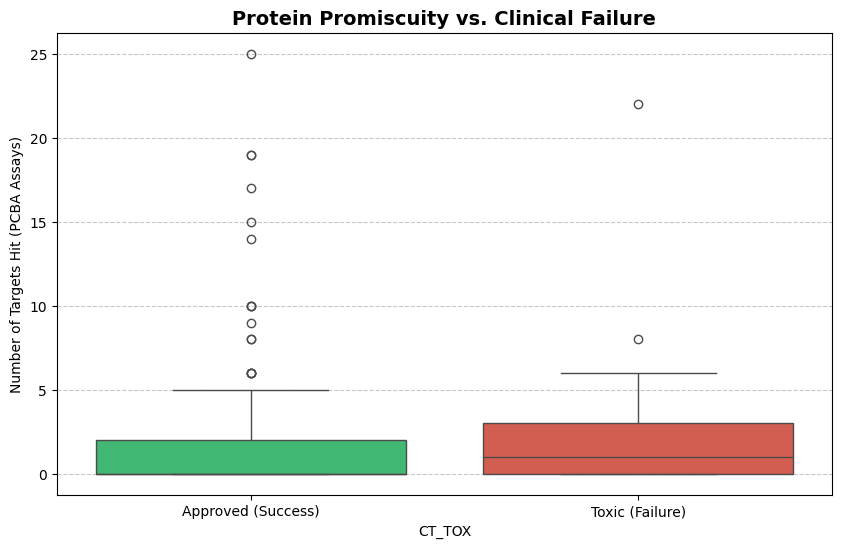

[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerat

Generating Fingerprints for UMAP (this may take a moment)...


[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerator
[16:57:52] DEPRECATION WARNING: please use MorganGenerat

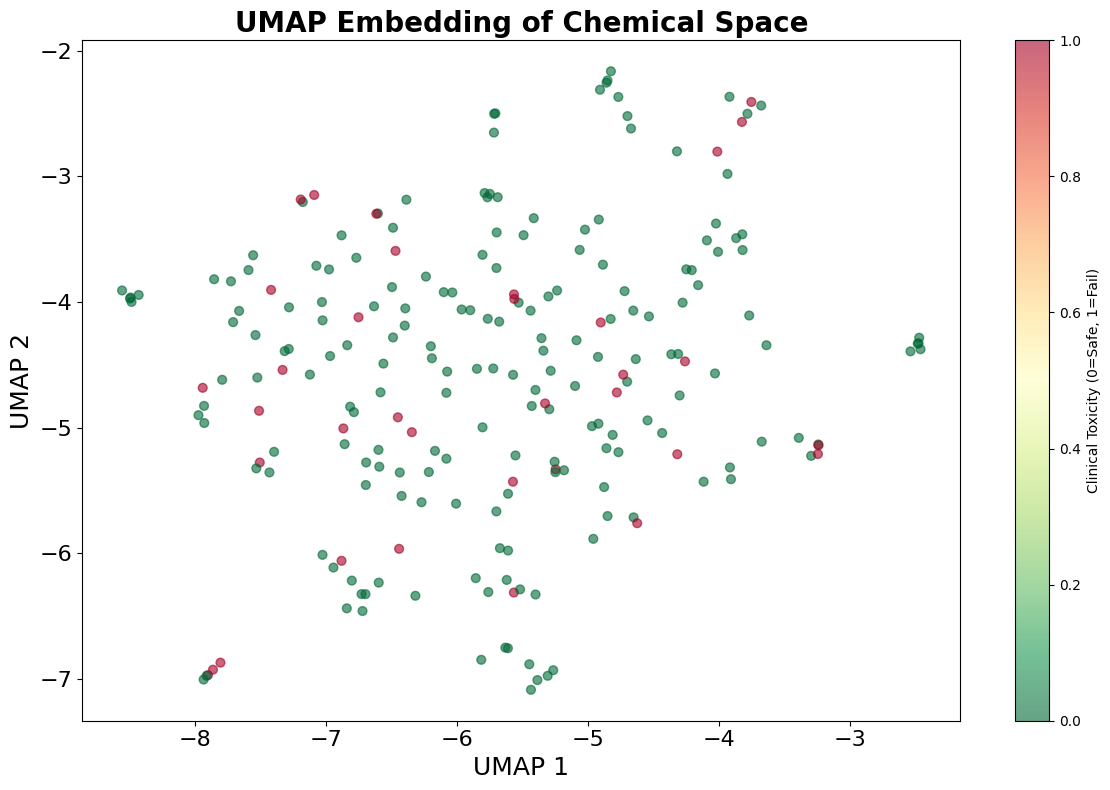

In [ ]:
#@title Another Visualization

!pip install -q umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from umap import UMAP

# --- PART 1: Promiscuity vs. Clinical Outcome ---
# Count how many PCBA assays each molecule is active in
merged['Promiscuity_Score'] = merged[pcba_tasks].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged, x='CT_TOX', y='Promiscuity_Score', palette=['#2ecc71', '#e74c3c'])
plt.title('Protein Promiscuity vs. Clinical Failure', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Approved (Success)', 'Toxic (Failure)'])
plt.ylabel('Number of Targets Hit (PCBA Assays)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- PART 2: UMAP Chemical Space Embedding ---
print("Generating Fingerprints for UMAP (this may take a moment)...")

def get_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Generate 2048-bit Morgan Fingerprint (radius 2)
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
    return np.zeros(2048)

# Sample the data if it's too large for UMAP performance (e.g., >10k rows)
# Here we use the whole 'merged' set
fps = np.stack(merged['smiles'].apply(get_fp))

# Run UMAP
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(fps)

merged['umap_1'] = embedding[:, 0]
merged['umap_2'] = embedding[:, 1]

# --- Plotting the Chemical Space ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    merged['umap_1'],
    merged['umap_2'],
    c=merged['CT_TOX'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=40
)

plt.colorbar(scatter, label='Clinical Toxicity (0=Safe, 1=Fail)')
plt.title('UMAP Embedding of Chemical Space', fontsize=20, fontweight='bold')
plt.xlabel('UMAP 1', fontsize=18)
plt.ylabel('UMAP 2', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

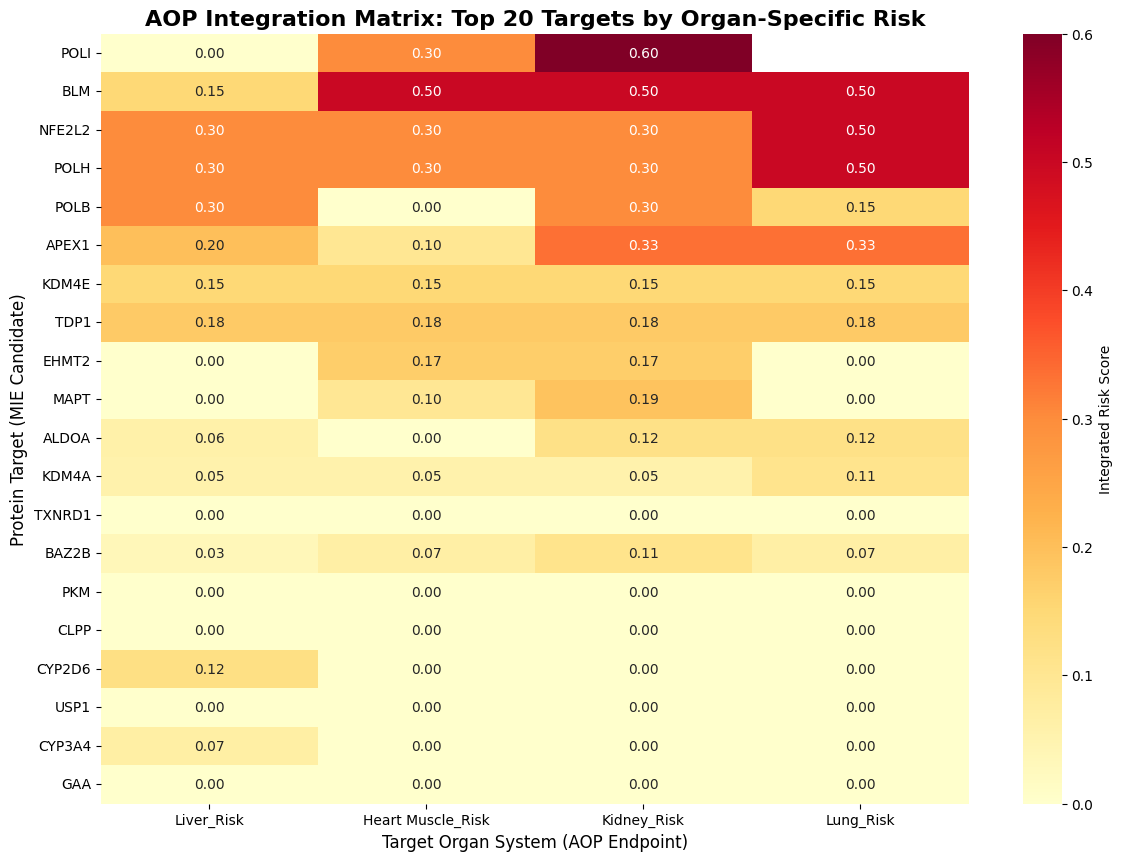


MASTER AOP INTEGRATION TABLE (Top 15 Targets)


,Protein,Actives,Tox_Fraction,Final_Score,Liver_Risk,Heart Muscle_Risk,Kidney_Risk
0,POLI,1,1.000000,0.787714,0.000000,0.300000,0.600000
1,BLM,2,0.500000,0.600274,0.150000,0.500000,0.500000
2,NFE2L2,6,0.500000,0.544455,0.300000,0.300000,0.300000
3,POLH,2,0.500000,0.508734,0.300000,0.300000,0.300000
4,POLB,2,0.500000,0.451495,0.300000,0.000000,0.300000
5,APEX1,3,0.333333,0.427149,0.200000,0.100000,0.333333
6,KDM4E,4,0.250000,0.385759,0.150000,0.150000,0.150000
7,TDP1,91,0.297619,0.312976,0.178571,0.178571,0.178571
8,EHMT2,14,0.285714,0.278571,0.000000,0.171429,0.171429
9,MAPT,9,0.321429,0.256230,0.000000,0.096429,0.192857



INTEGRATION TIP: Use 'Tox_Fraction' as the probability weight for your AOP MIE edges.


In [ ]:
#@title Integration Output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

# --- 1. Master Data Aggregation ---
# We use the 'final_integration' and 'validation_df' created in your previous steps
# If they don't exist, we'll merge the key metrics now.

def generate_aop_summary_table():
    # Ensure Protein names are consistent
    results_df['Protein'] = results_df['Protein'].str.upper()

    # Merge Toxicity Statistics with Tissue Expression (HPA)
    # This combines: Clinical Failure Rate + Tissue Presence
    master_df = pd.merge(
        results_df[['Protein', 'Actives', 'Tox_Fraction', 'Final_Score']],
        tissue_pivot,
        left_on='Protein', right_on='Gene name',
        how='inner'
    ).drop(columns=['Gene name'])

    # Merge with SIDER Clinical Validation (if available)
    # This tells us: "Of the drugs hitting this protein, how many caused X disorder in humans?"
    if 'validation_df' in locals() or 'validation_df' in globals():
        master_df = pd.merge(master_df, validation_df.reset_index(), on='Protein', how='left')

    # --- 2. Calculate Organ-Specific Risk Scores ---
    # Formula: Risk = (Protein Toxicity Enrichment) * (Tissue Expression Level)
    tissues = ['liver', 'heart muscle', 'kidney', 'brain', 'lung']
    for tissue in tissues:
        if tissue in master_df.columns:
            master_df[f'{tissue.title()}_Risk'] = master_df['Tox_Fraction'] * master_df[tissue]

    return master_df

# Execute the merge
aop_master_data = generate_aop_summary_table()

# --- 3. Visualization: The "AOP Seed" Heatmap ---
plt.figure(figsize=(14, 10))
risk_cols = [c for c in aop_master_data.columns if '_Risk' in c]
heatmap_data = aop_master_data.set_index('Protein')[risk_cols].head(20)

sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Integrated Risk Score'})
plt.title("AOP Integration Matrix: Top 20 Targets by Organ-Specific Risk", fontsize=16, fontweight='bold')
plt.xlabel("Target Organ System (AOP Endpoint)", fontsize=12)
plt.ylabel("Protein Target (MIE Candidate)", fontsize=12)
plt.show()

# --- 4. Final Formatted Table Output ---
print("\n" + "="*100)
print("MASTER AOP INTEGRATION TABLE (Top 15 Targets)")
print("="*100)
display_cols = ['Protein', 'Actives', 'Tox_Fraction', 'Final_Score', 'Liver_Risk', 'Heart Muscle_Risk', 'Kidney_Risk']
# Filter to columns that actually exist
existing_display = [c for c in display_cols if c in aop_master_data.columns]

display(aop_master_data[existing_display].sort_values(by='Final_Score', ascending=False).head(15))

print("\nINTEGRATION TIP: Use 'Tox_Fraction' as the probability weight for your AOP MIE edges.")

In [ ]:
#@title Chem Output
import pandas as pd

def identify_screening_candidates(target_protein, n_compounds=10):
    """
    Identifies specific compounds to screen or study based on
    their activity against a high-risk AOP target.
    """
    # 1. Identify which PCBA assays map to this protein
    relevant_assays = [aid for aid, prot in pcba_protein_map.items() if prot == target_protein]

    if not relevant_assays:
        return f"No assays found for protein: {target_protein}"

    # 2. Filter merged data for compounds active in ANY of these assays
    # We also pull in the promiscuity score we calculated earlier
    candidates = merged[merged[relevant_assays].sum(axis=1) > 0].copy()

    if candidates.empty:
        return f"No active compounds found in the merged dataset for: {target_protein}"

    # 3. Rank by Risk Profile
    # We prioritize compounds that are both Active AND have a high Promiscuity_Score
    # as these are most likely to trigger multi-organ AOPs.
    candidates = candidates.sort_values(by=['CT_TOX', 'Promiscuity_Score'], ascending=False)

    # 4. Format for presentation
    display_df = candidates[['smiles', 'CT_TOX', 'Promiscuity_Score']].head(n_compounds)
    display_df.columns = ['SMILES', 'Clinical_Tox_Known', 'Target_Promiscuity']

    return display_df

# --- EXECUTION: Top 3 High-Risk Targets ---
top_targets = results_df.head(3)['Protein'].tolist()

print("="*80)
print("PROPOSED SCREENING CANDIDATES FOR AOP VALIDATION")
print("="*80)

for protein in top_targets:
    print(f"\n>>> Target: {protein} (Top Risk Protein)")
    result = identify_screening_candidates(protein)
    if isinstance(result, pd.DataFrame):
        display(result)
    else:
        print(result)

print("\nSCREENING STRATEGY:")
print("1. RED FLAGS: SMILES with Clinical_Tox_Known = 1 are your 'Positive Controls'.")
print("2. DARK CHEMICAL MATTER: High Promiscuity compounds with Tox = 0 are candidates for deeper PBPK modeling.")

PROPOSED SCREENING CANDIDATES FOR AOP VALIDATION

>>> Target: POLI (Top Risk Protein)


,SMILES,Clinical_Tox_Known,Target_Promiscuity
33,O=C1c2c(O)ccc(O)c2C(=O)c2c(NCCNCCO)ccc(NCCNCCO...,1,22



>>> Target: BLM (Top Risk Protein)


,SMILES,Clinical_Tox_Known,Target_Promiscuity
33,O=C1c2c(O)ccc(O)c2C(=O)c2c(NCCNCCO)ccc(NCCNCCO...,1,22
147,O=C1OC2(c3ccc(O)cc3Oc3cc(O)ccc32)c2ccccc21,0,4



>>> Target: NFE2L2 (Top Risk Protein)


,SMILES,Clinical_Tox_Known,Target_Promiscuity
110,O=C(CCCCCCC(=O)Nc1ccccc1)NO,1,5
7,Oc1c(Cl)cc(Cl)c(Cl)c1Cc1c(O)c(Cl)cc(Cl)c1Cl,0,25
211,COC(=O)C1=C(C)NC(C)=C(C(=O)OCC(C)C)C1c1ccccc1[...,0,14
69,CCOC(=O)c1ncn2c1CN(C)C(=O)c1cc(F)ccc1-2,0,1
78,CC1(C)O[C@@H]2C[C@H]3[C@@H]4CCC5=CC(=O)C=C[C@]...,0,1
160,Cc1ncc(C[n+]2csc(CCO)c2C)c(N)n1,0,1



SCREENING STRATEGY:
1. RED FLAGS: SMILES with Clinical_Tox_Known = 1 are your 'Positive Controls'.
2. DARK CHEMICAL MATTER: High Promiscuity compounds with Tox = 0 are candidates for deeper PBPK modeling.


In [ ]:
#@title Not working AOP integration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# --- 1. DATA PREPARATION (Clinical Integration) ---
# We represent the MASTER AOP INTEGRATION TABLE as a dictionary for the model
clinical_tox_data = {
    "POLI":   {"tox_fraction": 1.000, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "BLM":    {"tox_fraction": 0.500, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "NFE2L2": {"tox_fraction": 0.500, "target_ao": "hepatotoxicity", "ke": "oxidative_stress"},
    "POLH":   {"tox_fraction": 0.500, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "POLB":   {"tox_fraction": 0.500, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "APEX1":  {"tox_fraction": 0.333, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "TDP1":   {"tox_fraction": 0.297, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "EHMT2":  {"tox_fraction": 0.285, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "MAPT":   {"tox_fraction": 0.321, "target_ao": "neurotoxicity",   "ke": "neurotransmitter_disruption"},
    "ALDOA":  {"tox_fraction": 0.200, "target_ao": "hepatotoxicity", "ke": "mitochondrial_dysfunction"},
    "KDM4A":  {"tox_fraction": 0.181, "target_ao": "carcinogenicity", "ke": "genomic_instability"},
    "BAZ2B":  {"tox_fraction": 0.111, "target_ao": "carcinogenicity", "ke": "genomic_instability"}
}

def run_clinical_aop_simulation(df_pbpk, df_binding):
    # Map Proteins to MIEs
    # Each protein is treated as a unique MIE to preserve clinical precision
    mie_map = {prot: f"{prot}_perturbation" for prot in clinical_tox_data.keys()}

    # Initialize Network Structures
    aop_edges = []
    nodes = []

    # Generate Edges dynamically using Tox_Fraction
    for protein, info in clinical_tox_data.items():
        mie_node = mie_map[protein]
        ke_node = info["ke"]
        ao_node = info["target_ao"]

        # MIE -> KE weighted by Clinical Tox_Fraction
        aop_edges.append((mie_node, ke_node, info["tox_fraction"]))
        # KE -> AO (Standard downstream propagation)
        aop_edges.append((ke_node, ao_node, 0.9))

        nodes.extend([mie_node, ke_node, ao_node])

    # Inter-KE propagation (e.g., Stress leads to Mitochondrial damage)
    aop_edges.append(("oxidative_stress", "mitochondrial_dysfunction", 0.8))
    aop_edges.append(("mitochondrial_dysfunction", "hepatotoxicity", 0.9))

    # --- 2. COMPUTE PERTURBATION ---
    df_merged = pd.merge(df_pbpk, df_binding, on=["compound", "tissue"])
    df_merged["occupancy"] = df_merged["Cmax_unbound_uM"] / (df_merged["Cmax_unbound_uM"] + df_merged["predicted_Kd_uM"])
    df_merged["perturbation"] = expit(df_merged["occupancy"].fillna(0))
    df_merged["MIE"] = df_merged["protein"].map(mie_map)

    # --- 3. NETWORK PROPAGATION ---
    node_activity = {node: 0.0 for node in set(nodes)}

    # Seed MIEs
    for _, row in df_merged.dropna(subset=["MIE"]).iterrows():
        if row["MIE"] in node_activity:
            node_activity[row["MIE"]] += row["perturbation"]

    # Iterate propagation
    for _ in range(5):
        for source, target, weight in aop_edges:
            node_activity[target] += node_activity[source] * weight

    # --- 4. OUTPUT RESULTS ---
    ao_list = ["hepatotoxicity", "nephrotoxicity", "cardiotoxicity", "neurotoxicity", "carcinogenicity"]
    final_scores = {ao: expit(node_activity.get(ao, 0)) for ao in ao_list}

    df_ao = pd.DataFrame(list(final_scores.items()), columns=["Adverse_Outcome", "Risk_Score"])

    # Plotting
    df_ao.sort_values("Risk_Score", ascending=True).plot(kind="barh", x="Adverse_Outcome", color='crimson', figsize=(10, 5))
    plt.title("Clinically-Weighted AOP Risk Assessment", fontweight='bold')
    plt.xlabel("Predicted Risk Probability")
    plt.show()

    return df_ao

# Run the simplified module
risk_results = run_clinical_aop_simulation(df_pbpk, df_binding)

NameError: name 'df_pbpk' is not defined